# 08 — Training dynamics: saturation, initialization, learning rate, gradient flow

Correct derivatives do not guarantee good optimization.

## What you should learn
- why sigmoid/tanh saturation shrinks gradients;
- why initialization scale matters;
- how depth multiplies local derivatives;
- how gradient norms expose vanishing/exploding behavior;
- how to diagnose under-learning before changing architecture blindly.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(precision=5, suppress=True)
RNG = np.random.default_rng(42)


## 1. Activation and derivative together


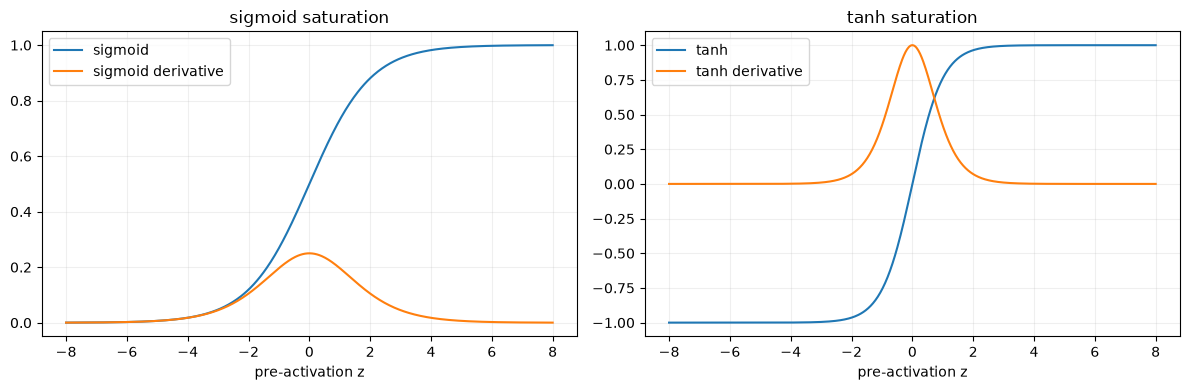

In [2]:
z=np.linspace(-8,8,600);sig=1/(1+np.exp(-z));ds=sig*(1-sig);th=np.tanh(z);dth=1-th**2
fig,axes=plt.subplots(1,2,figsize=(12,4));axes[0].plot(z,sig,label='sigmoid');axes[0].plot(z,ds,label='sigmoid derivative');axes[1].plot(z,th,label='tanh');axes[1].plot(z,dth,label='tanh derivative')
for ax in axes:ax.legend();ax.grid(alpha=.2);ax.set_xlabel('pre-activation z')
axes[0].set_title('sigmoid saturation');axes[1].set_title('tanh saturation');plt.tight_layout();plt.show()


When $|z|$ is large, the derivative approaches zero. Backprop multiplies by these local derivatives, so early layers can receive tiny gradients.


## 2. Gradient propagation through depth


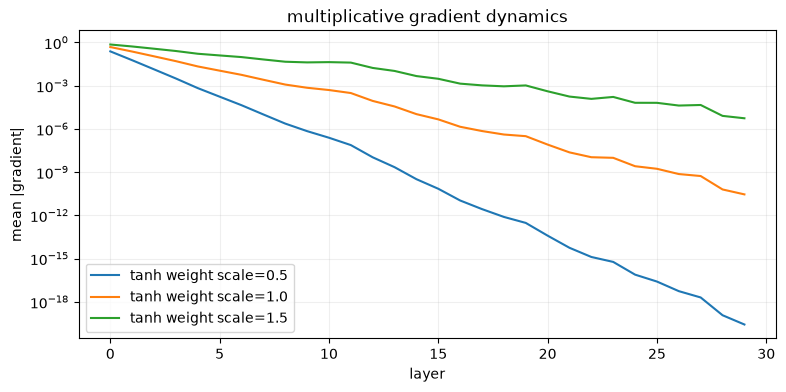

In [3]:
def simulate(depth,scale,act='tanh',n=5000):
    rng=np.random.default_rng(1);g=np.ones(n);vals=[]
    for layer in range(depth):
        z=rng.normal(size=n);w=rng.normal(0,scale,size=n)
        local=(1-np.tanh(z)**2) if act=='tanh' else (z>0).astype(float)
        g=g*w*local;vals.append(np.mean(np.abs(g)))
    return np.array(vals)
fig,ax=plt.subplots(figsize=(9,4))
for s in [.5,1.0,1.5]:ax.plot(simulate(30,s),label=f'tanh weight scale={s}')
ax.set_yscale('log');ax.set_xlabel('layer');ax.set_ylabel('mean |gradient|');ax.set_title('multiplicative gradient dynamics');ax.legend();ax.grid(alpha=.2);plt.show()


## 3. Learning-rate behavior on the real digits training loop


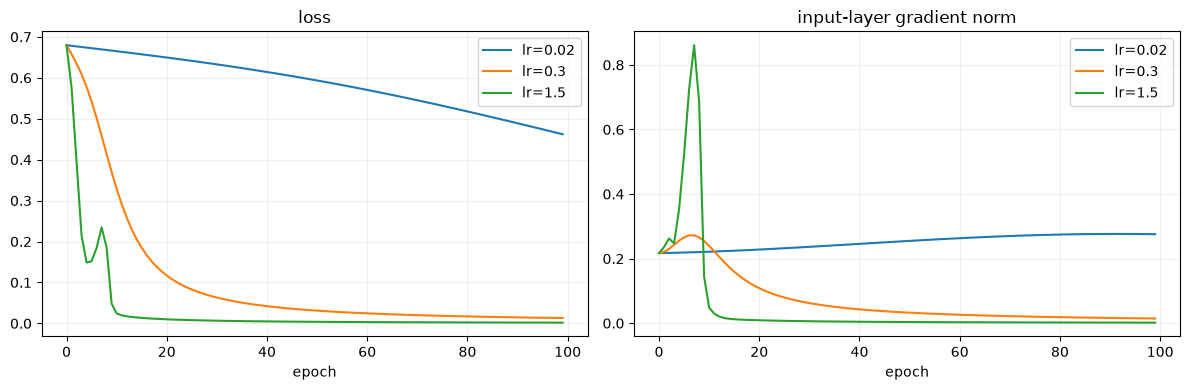

In [4]:
from sklearn.datasets import load_digits
d=load_digits();m=np.isin(d.target,[0,1]);X=d.data[m]/16.;y=(d.target[m]==1).astype(float).reshape(-1,1)
def curve(lr,scale,epochs=100):
    rng=np.random.default_rng(3);W1=rng.normal(0,scale,(64,8));b1=np.zeros((1,8));W2=rng.normal(0,scale,(8,1));b2=np.zeros((1,1));out=[]
    for ep in range(epochs):
        h=np.tanh(X@W1+b1);p=1/(1+np.exp(-(h@W2+b2)));e=1e-9;loss=-np.mean(y*np.log(p+e)+(1-y)*np.log(1-p+e));dz=(p-y)/len(X);dW2=h.T@dz;dh=dz@W2.T;dz1=dh*(1-h**2);dW1=X.T@dz1
        out.append((loss,np.linalg.norm(dW1)));W2-=lr*dW2;b2-=lr*dz.sum(0,keepdims=True);W1-=lr*dW1;b1-=lr*dz1.sum(0,keepdims=True)
    return np.array(out)
fig,axes=plt.subplots(1,2,figsize=(12,4))
for lr in [.02,.3,1.5]:
    c=curve(lr,.15);axes[0].plot(c[:,0],label=f'lr={lr}');axes[1].plot(c[:,1],label=f'lr={lr}')
axes[0].set_title('loss');axes[1].set_title('input-layer gradient norm')
for ax in axes:ax.legend();ax.grid(alpha=.2);ax.set_xlabel('epoch')
plt.tight_layout();plt.show()


## Diagnostic checklist
- **loss flat + gradients tiny:** saturation, poor scaling, too-deep signal path, dead units;
- **loss oscillating/diverging:** learning rate too large, exploding gradients, numerical instability;
- **training improves but validation fails:** overfitting / data mismatch;
- **both poor with healthy gradients:** capacity, features, objective, labels, or data quality may be wrong.
